## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Methode für klassische Nullstellensuche mit _Mitternachtsformel_:

In [2]:
def zerosquadpol(a,b):
    z = np.array([])
    D = a**2 - 4*b # vectorized
    if D.any()<0: 
        print('no real zeros')
    else:
        wD = np.sqrt(D)
        z = np.array([ (-a-wD)/2 , (-a+wD)/2 ])
        
        return(z)

Setze Vektoren für a und b so dass genau $c$ und $\frac{1}{c}$ die Lösungen sind.

In [3]:
n = 100
c = np.linspace(2, 1000, n+1, endpoint=True)
a = -(c+1/c)
b = 1

Berechne die Nullstellen und vergleiche mit den tatsächlichen Nullstellen:

In [4]:
z0, z1 = zerosquadpol(a,b) # Fehlerbehaftete Berechnung
x0 = 1/c   # tatsächliche Nullstelle 0
x1 = c     # tatsächliche Nullstelle 1

## Plot
Hier sehen wir den Fehler der Nullstellensuche mithilfe der normalen quadratischen Gleichung, der aufgrund der ungenauen Zahlendarstellung des Computers passiert (Auslöschung bei kleiner Nullstelle):

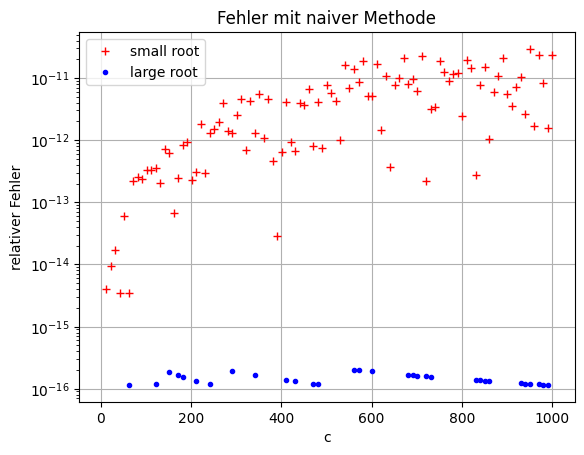

In [5]:
plt.title("Fehler mit naiver Methode")
plt.semilogy(c, abs(z0-x0)/x0, 'r+', label='small root')
plt.semilogy(c, abs(z1-x1)/x1, 'b.', label='large root')
plt.ylabel('relativer Fehler')
plt.xlabel('c')
plt.grid()
plt.legend()
plt.show()

## Alternative variante
Um die Auslöschung zu verhindern, suchen wir wieder nach der 'grossen Wurzel' von vorher und nutzen, dass $x_0 = \frac{1}{x_1}$ für die beiden Nullstellen. So berechnen wir die zweite Nullstelle _ohne_ subtraktion. 

In [6]:
def stabzerosquadpol(a,b):
    z = np.array([])
    D = a**2 - 4*b
    if D.any()<0: 
        print('no real zeros')
    else:
        wD = np.sqrt(D)
        z2 = np.where(a<0, (wD-a)/2, (-wD-a)/2)
        z1 = b/z2
        z = np.array([z1, z2])
        return(z)

Aufruf der Methode:

In [7]:
y0, y1 = stabzerosquadpol(a,b) # Verbesserte Berechnung

Plot im Vergleich:

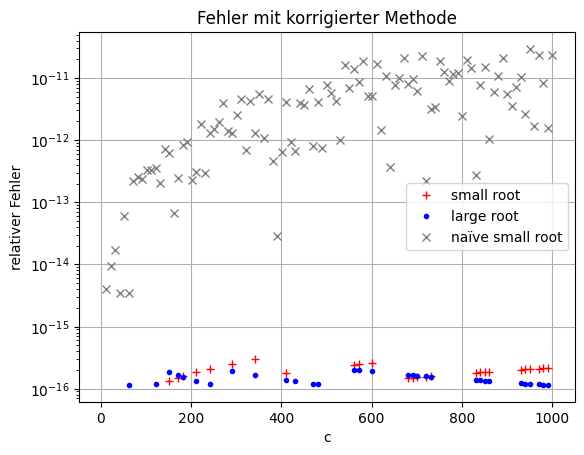

In [8]:
plt.title("Fehler mit korrigierter Methode")
plt.semilogy(c, abs(y0-x0)/x0, 'r+', label='small root')
plt.semilogy(c, abs(y1-x1)/x1, 'b.', label='large root')
plt.semilogy(c, abs(z0-x0)/x0, 'x', label='naïve small root', color="gray")
plt.ylabel('relativer Fehler')
plt.xlabel('c')
plt.grid()
plt.legend()
plt.show()